In [15]:
import os
import sys

sys.path.append(os.path.join(os.path.dirname(os.getcwd())))
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), "src"))


In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [40]:
from matplotlib import pyplot as plt

plt.style.use(["science"])

%matplotlib inline
%config InlineBackend.figure_format='retina'

2025-12-04 22:29:11 DEBUG    matplotlib.pyplot: Loaded backend inline version unknown.


In [17]:
import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedGroupKFold
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from src.probing_dataset import make_sentence_level_probing_dataset, make_word_level_probing_dataset
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [18]:
from dataclasses import dataclass

@dataclass
class ProbingDataset:
    model_name: str
    hiddens_path: Path
    instruct: bool
    sentence_level_dataset: pd.DataFrame | None = None
    word_level_dataset: pd.DataFrame | None = None

probing_datasets = [
    ProbingDataset(
        model_name="ai-sage/GigaChat3-10B-A1.8B-base",
        instruct=False,
        hiddens_path=Path("../src/results/ai-sage_GigaChat3-10B-A1.8B-base"),
    ),
    ProbingDataset(
        model_name="Qwen/Qwen2.5-7B",
        instruct=False,
        hiddens_path=Path("../src/results/Qwen_Qwen2.5-7B"),
    ),
    # ProbingDataset(
    #     model_name="meta-llama/Meta-Llama-3-8B",
    #     instruct=False,
    #     hiddens_path=Path("../src/results/meta-llama_Meta-Llama-3-8B")
    # )
]

for probing_dataset in tqdm(probing_datasets, desc="Load probing dataset"):
    probing_dataset.sentence_level_dataset = make_sentence_level_probing_dataset(
        model_name=probing_dataset.model_name,
        instruct=probing_dataset.instruct,
        model_hiddens_path=probing_dataset.hiddens_path,
        stimuli_csv_path=Path("../hf_datasets/stimuli.csv")
    )
    probing_dataset.word_level_dataset = make_word_level_probing_dataset(
        model_name=probing_dataset.model_name,
        instruct=probing_dataset.instruct,
        model_hiddens_path=probing_dataset.hiddens_path,
        stimuli_csv_path=Path("../hf_datasets/stimuli.csv")
    )

probing_datasets_dict = {probing_dataset.model_name: probing_dataset for probing_dataset in probing_datasets}

Load probing dataset:   0%|          | 0/2 [00:00<?, ?it/s]2025-12-04 21:28:08 DEBUG    urllib3.connectionpool: Starting new HTTPS connection (1): huggingface.co:443
2025-12-04 21:28:09 DEBUG    urllib3.connectionpool: https://huggingface.co:443 "HEAD /ai-sage/GigaChat3-10B-A1.8B-base/resolve/main/tokenizer_config.json HTTP/1.1" 307 0
2025-12-04 21:28:09 DEBUG    urllib3.connectionpool: https://huggingface.co:443 "HEAD /api/resolve-cache/models/ai-sage/GigaChat3-10B-A1.8B-base/8092e7006e188b65fe10526a1b6472576645e5ed/tokenizer_config.json HTTP/1.1" 200 0
2025-12-04 21:28:09 DEBUG    urllib3.connectionpool: https://huggingface.co:443 "GET /api/models/ai-sage/GigaChat3-10B-A1.8B-base/tree/main/additional_chat_templates?recursive=False&expand=False HTTP/1.1" 404 64
2025-12-04 21:28:09 DEBUG    urllib3.connectionpool: https://huggingface.co:443 "GET /api/models/ai-sage/GigaChat3-10B-A1.8B-base/tree/main?recursive=True&expand=False HTTP/1.1" 200 5597
2025-12-04 21:28:10 DEBUG    urllib3.con

## Код для обучения проб

In [21]:
def probe_layers(df, target_labels=["all"], random_state=42):
    df = df.copy()

    if target_labels != ["all"]:
        df = df[df["target"].isin(target_labels)]

    le = LabelEncoder()
    df["target_enc"] = le.fit_transform(df["target"])

    results = []
    per_layer_reports = []
    confusion_matrices = []
    best_acc = 0
    best_layer = None
    best_report = None
    best_conf = None

    cv = StratifiedGroupKFold(
        n_splits=5, shuffle=True, random_state=random_state
    )

    all_layer_accs = {}

    for layer in sorted(df["layer"].unique()):
        sub = df[df["layer"] == layer].reset_index(drop=True)

        X = np.stack(sub["hidden_state"].values)
        y = sub["target_enc"].values
        groups = sub["sentence_id"].values

        layer_accs = []

        for train_idx, test_idx in cv.split(X, y, groups):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

            clf = LogisticRegression(
                max_iter=500,
                n_jobs=-1,
                solver="lbfgs",
                multi_class="multinomial" if target_labels == ["all"] or len(target_labels) > 2 else "deprecated",
                random_state=random_state
            )
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)

            layer_accs.append(accuracy_score(y_test, y_pred))

        all_layer_accs[layer] = layer_accs

        acc = np.mean(layer_accs)
        results.append({"layer": int(layer), "accuracy": acc})

        report = classification_report(y_test, y_pred, target_names=le.classes_, output_dict=True)
        per_layer_reports.append(report)

        conf_matrix = confusion_matrix(y_test, y_pred)
        confusion_matrices.append(conf_matrix)

        if acc > best_acc:
            best_acc = acc
            best_layer = layer
            best_report = report
            best_conf = conf_matrix

    return (
        pd.DataFrame(results),
        per_layer_reports,
        confusion_matrices,
        best_layer,
        best_report,
        best_conf,
        all_layer_accs
    )

### Визуализация

In [66]:
def plot_min_max_corridor(all_layer_accs, color: str = "blue"):
    layers = sorted(all_layer_accs.keys())[1:]

    means = np.array([np.mean(all_layer_accs[l]) for l in layers])
    mins  = np.array([np.min(all_layer_accs[l]) for l in layers])
    maxs  = np.array([np.max(all_layer_accs[l]) for l in layers])

    plt.figure(figsize=(5, 2))

    plt.plot(layers, means, color=color)

    plt.fill_between(
        layers,
        mins,
        maxs,
        alpha=0.2,
        color=color
    )

    plt.xlabel("Layer")
    plt.xticks(ticks=[i + 1 for i in range(len(layers))])
    plt.ylabel("Accuracy")
    plt.ylim((0.2, 1))
    plt.grid(False)
    plt.legend()
    plt.show()

In [59]:
def plot_confusion_matrix(cm: np.ndarray, class_names: list[str], title: str = "Confusion Matrix"):

    fig, ax = plt.subplots(figsize=(6, 5))

    im = ax.imshow(cm, interpolation='nearest', cmap="viridis")

    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.set_ylabel("Count", rotation=-90, va="bottom")

    ax.set(
        xticks=np.arange(len(class_names)),
        yticks=np.arange(len(class_names)),
        xticklabels=class_names,
        yticklabels=class_names,
        ylabel="True label",
        xlabel="Predicted label",
        title=title
    )

    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="black" if cm[i, j] > thresh else "white",
                fontsize=12,
            )

    plt.grid(False)
    plt.tight_layout()
    plt.show()

### Sentence-level tokens probing

На какие вопросы пытаемся ответить:

- Кодирует ли LLM тип ошибки в глобальном представлении предложения.
- Отделимы ли типы ошибок линейным классификатором

Normal vs Grammar-incongruent

Normal vs Semantic-incongruent

Grammar-incongruent vs Grammar/Semantic-incongruent

### Word-level probing

In [24]:
probing_datasets_dict.keys()

dict_keys(['ai-sage/GigaChat3-10B-A1.8B-base', 'Qwen/Qwen2.5-7B'])

In [41]:
probing_results = {}
for k, v in tqdm(probing_datasets_dict.items(), desc="Probe fitting"):
    probing_results[k] = probe_layers(df=v.word_level_dataset)

Probe fitting:   0%|          | 0/2 [00:00<?, ?it/s]/opt/miniconda3/envs/nir-env/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | fals

Gigachat

In [43]:
(gc_wl_results,
 gc_wl_per_layer_reports,
 gc_wl_confusion_matrices,
 gc_wl_best_layer,
 gc_wl_best_report,
 gc_wl_best_conf,
 gc_wl_all_layer_accs) = probing_results["ai-sage/GigaChat3-10B-A1.8B-base"]

/var/folders/88/rz9pfrnd34q32tv5679ygvyh0000gn/T/ipykernel_45651/1109760298.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
2025-12-04 23:06:11 DEBUG    matplotlib.texmanager: family: serif, package: \usepackage{mathptmx}, font: Times, skipped: 
2025-12-04 23:06:11 DEBUG    matplotlib.texmanager: family: sans-serif, package: , font: sans-serif, skipped: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans
2025-12-04 23:06:11 DEBUG    matplotlib.texmanager: family: cursive, package: \usepackage{chancery}, font: Zapf Chancery, skipped: Apple Chancery, Textile
2025-12-04 23:06:11 DEBUG    matplotlib.texmanager: family: monospace, package: \usepackage{type1ec}, font: Computer Modern Typewriter, skipped: DejaVu Sans Mono, Bitstream Vera Sans Mono
2025-12-04 23:06:11 DEBUG    matplotlib.dviread: Dvi: /Users/ilyamikheev/.matplotlib/tex.cache/cc/87

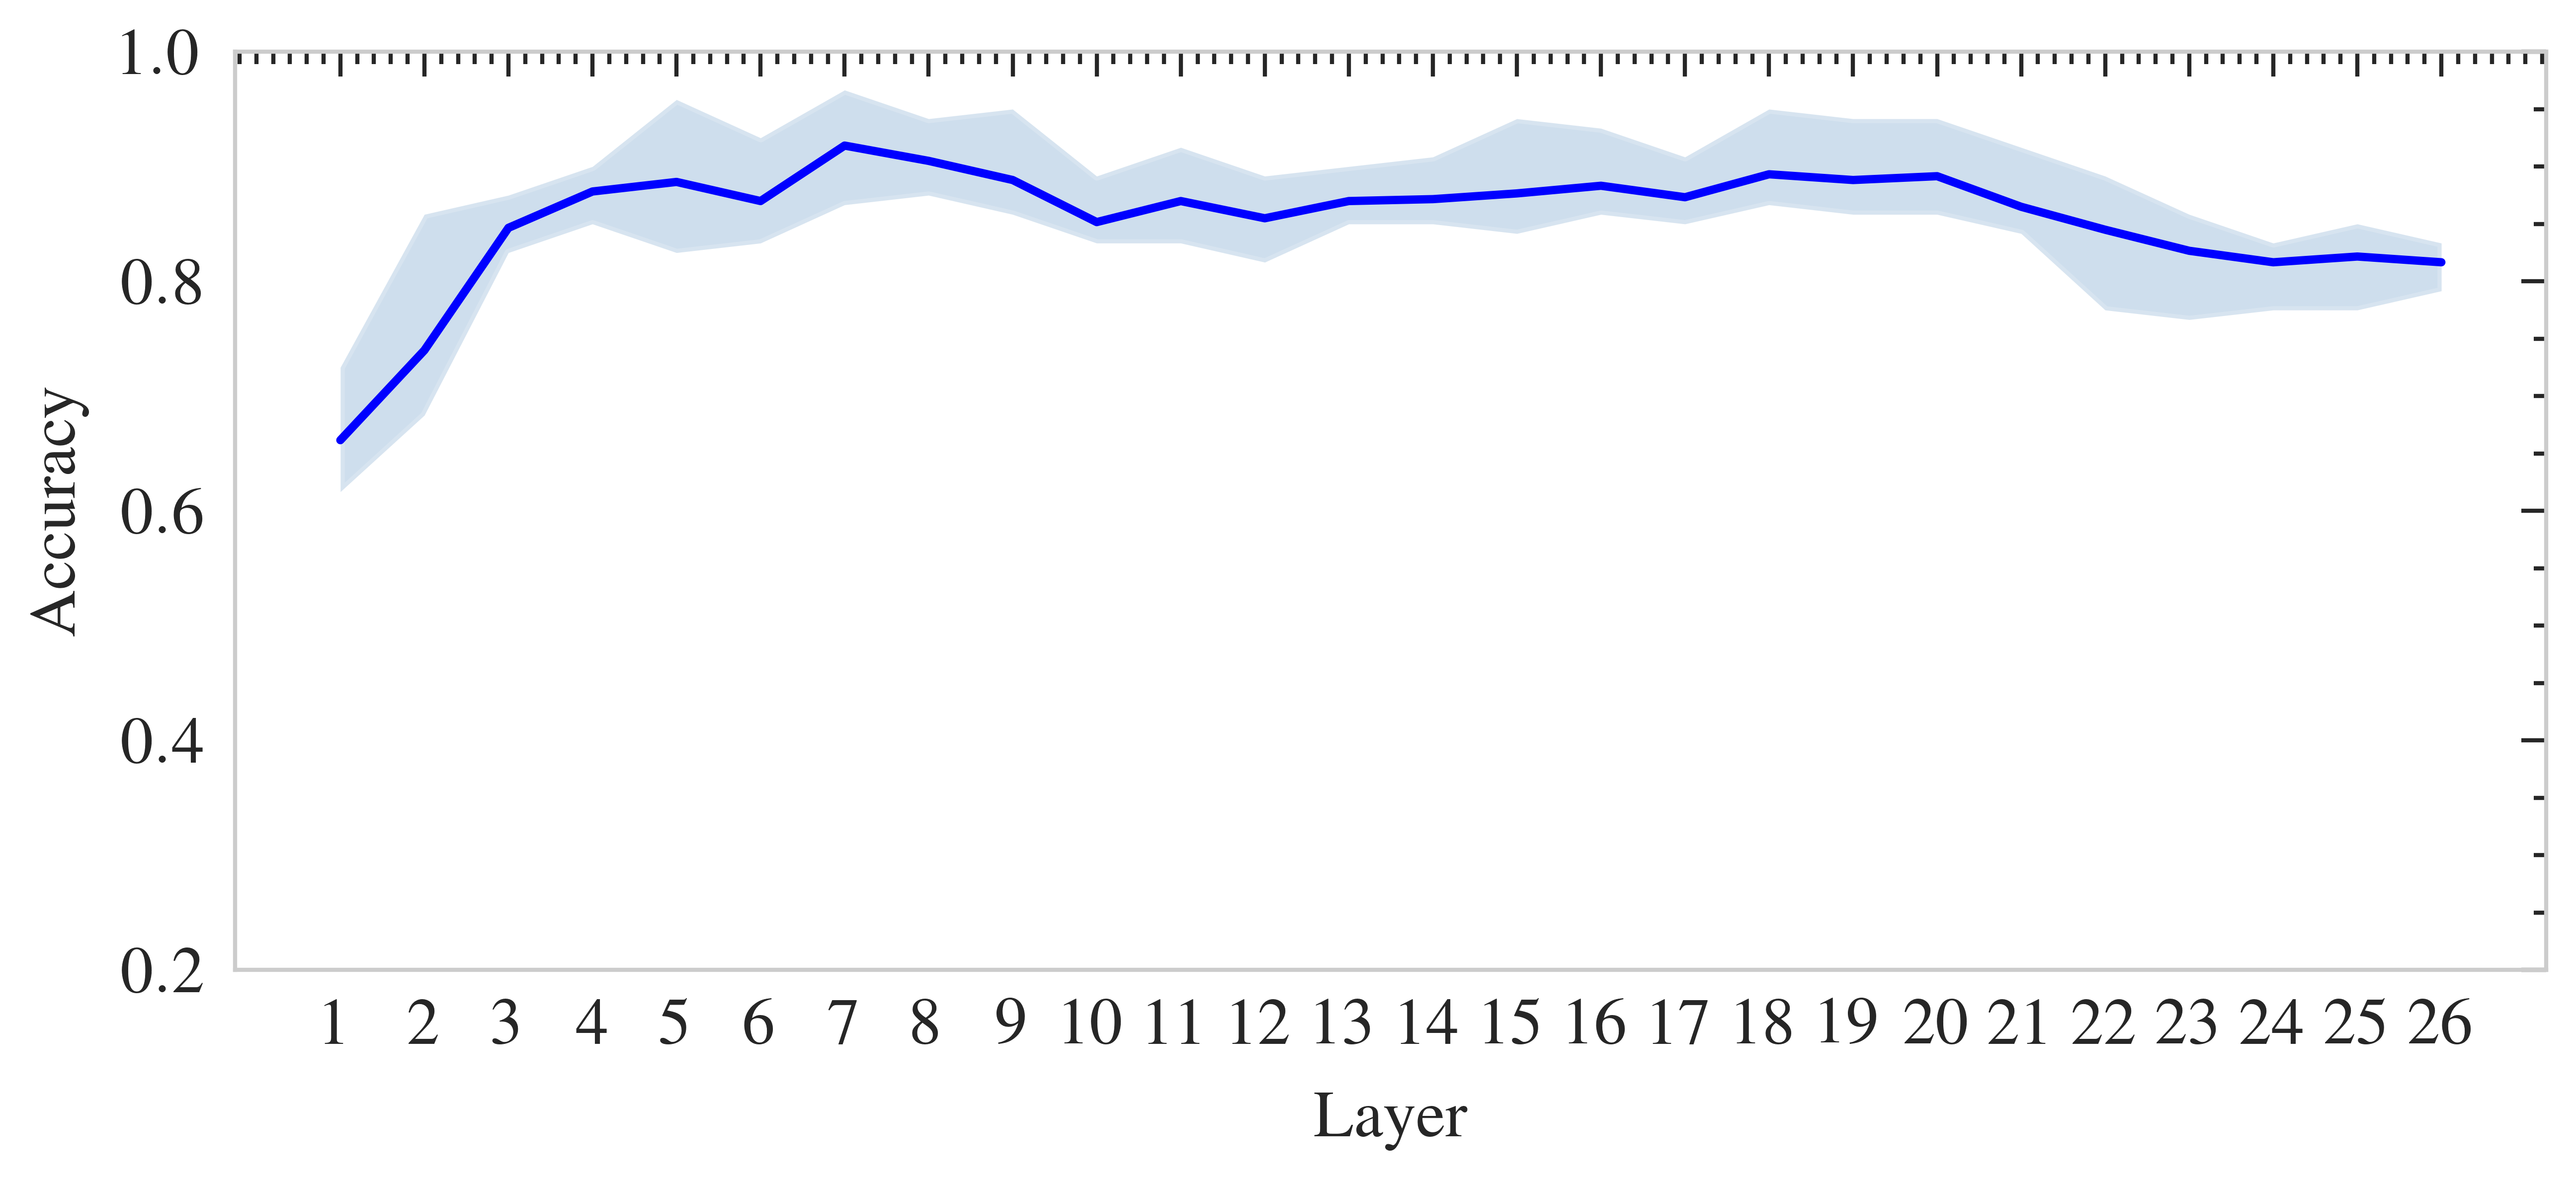

In [63]:
plot_min_max_corridor(gc_wl_all_layer_accs)

In [49]:
gc_wl_best_conf

array([[27,  1,  0,  2],
       [ 1, 27,  2,  0],
       [ 0,  0, 27,  3],
       [ 1,  0,  3, 26]])

2025-12-04 22:49:39 DEBUG    matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x3421bd7f0>
2025-12-04 22:49:39 DEBUG    matplotlib.texmanager: family: serif, package: \usepackage{mathptmx}, font: Times, skipped: 
2025-12-04 22:49:39 DEBUG    matplotlib.texmanager: family: sans-serif, package: , font: sans-serif, skipped: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans
2025-12-04 22:49:39 DEBUG    matplotlib.texmanager: family: cursive, package: \usepackage{chancery}, font: Zapf Chancery, skipped: Apple Chancery, Textile
2025-12-04 22:49:39 DEBUG    matplotlib.texmanager: family: monospace, package: \usepackage{type1ec}, font: Computer Modern Typewriter, skipped: DejaVu Sans Mono, Bitstream Vera Sans Mono
2025-12-04 22:49:39 DEBUG    matplotlib.dviread: Dvi: /Users/ilyamikheev/.matplotlib/tex.cache/cc/87/cc870fece1f1d8c03f0c28a153846cdcaffcfd008433626efcf5398762972285.dvi
2025-12-04 22:49:39 DEBUG    matplotlib.dviread: Dvi._xxx: encountered special: heade

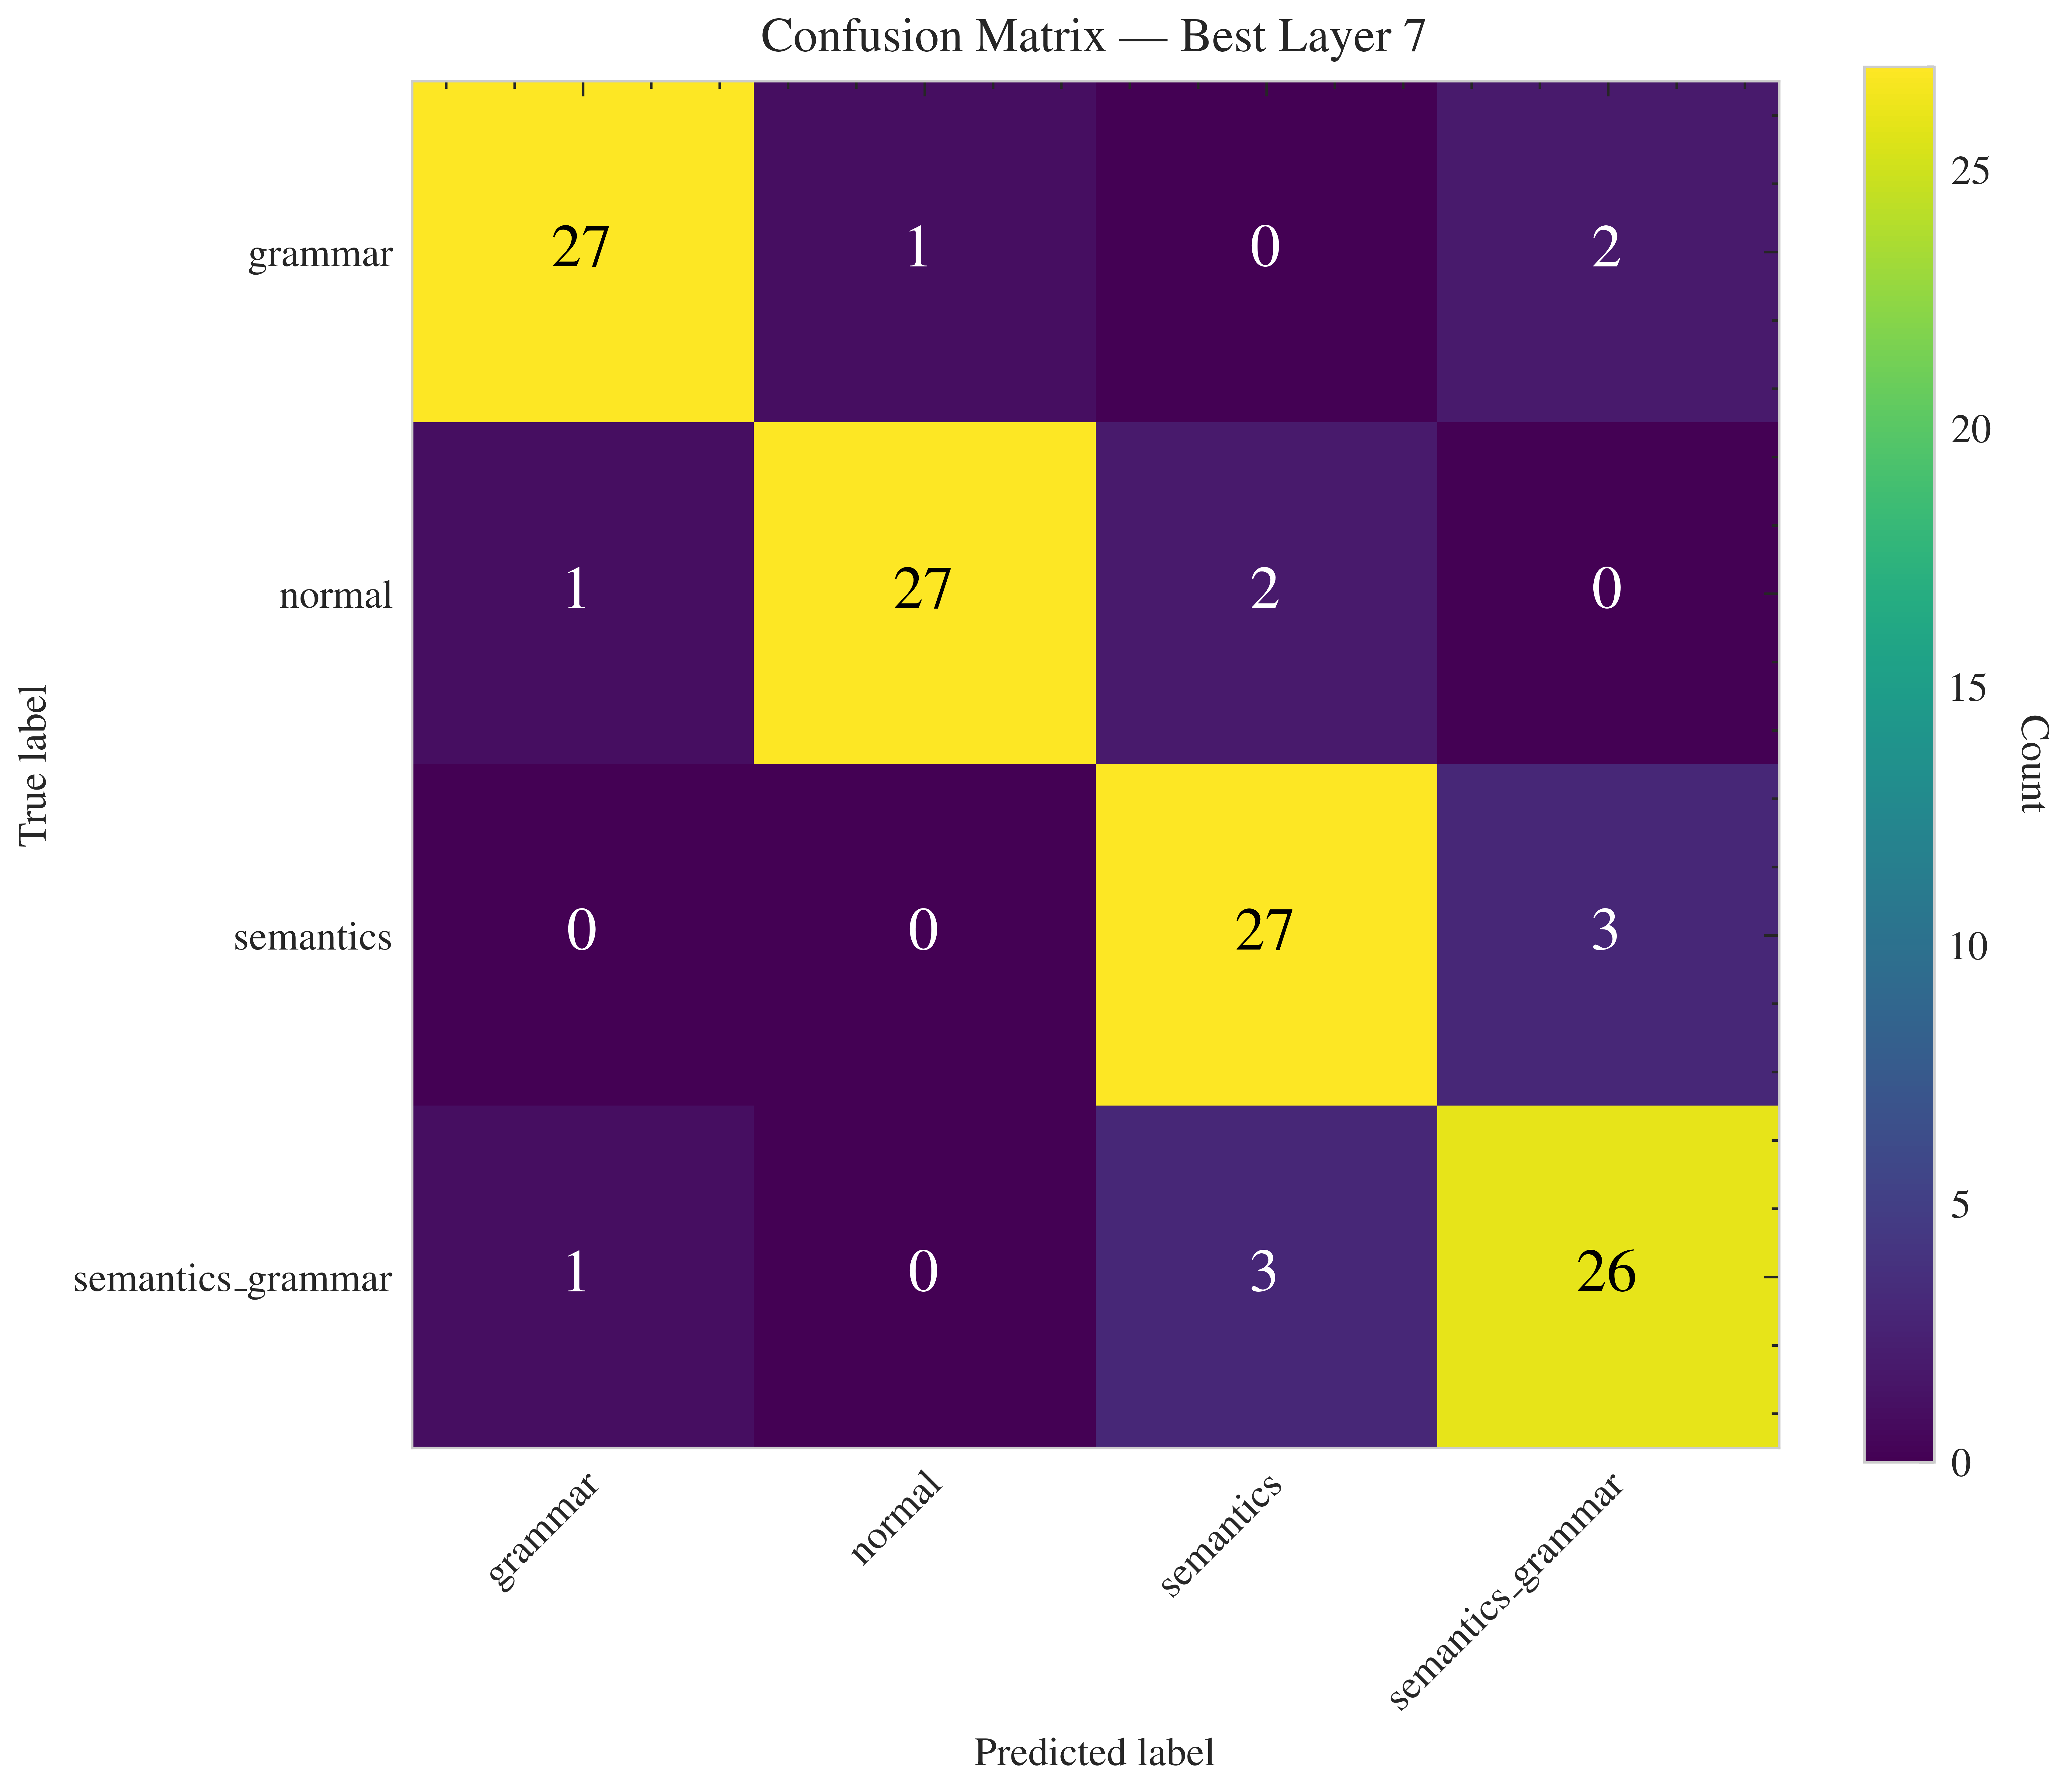

In [60]:
plot_confusion_matrix(
    gc_wl_best_conf,
    class_names=list(gc_wl_best_report.keys())[:-3],
    title=f"Confusion Matrix — Best Layer {gc_wl_best_layer}"
)

rQwen2.5-7B

In [67]:
(qw_wl_results,
 qw_wl_per_layer_reports,
 qw_wl_confusion_matrices,
 qw_wl_best_layer,
 qw_wl_best_report,
 qw_wl_best_conf,
 qw_wl_all_layer_accs) = probing_results["Qwen/Qwen2.5-7B"]

2025-12-04 23:16:33 DEBUG    matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x3471100b0>
2025-12-04 23:16:33 DEBUG    matplotlib.texmanager: family: serif, package: \usepackage{mathptmx}, font: Times, skipped: 
2025-12-04 23:16:33 DEBUG    matplotlib.texmanager: family: sans-serif, package: , font: sans-serif, skipped: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans
2025-12-04 23:16:33 DEBUG    matplotlib.texmanager: family: cursive, package: \usepackage{chancery}, font: Zapf Chancery, skipped: Apple Chancery, Textile
2025-12-04 23:16:33 DEBUG    matplotlib.texmanager: family: monospace, package: \usepackage{type1ec}, font: Computer Modern Typewriter, skipped: DejaVu Sans Mono, Bitstream Vera Sans Mono
2025-12-04 23:16:33 DEBUG    matplotlib.dviread: Dvi: /Users/ilyamikheev/.matplotlib/tex.cache/cc/87/cc870fece1f1d8c03f0c28a153846cdcaffcfd008433626efcf5398762972285.dvi
2025-12-04 23:16:33 DEBUG    matplotlib.dviread: Dvi._xxx: encountered special: heade

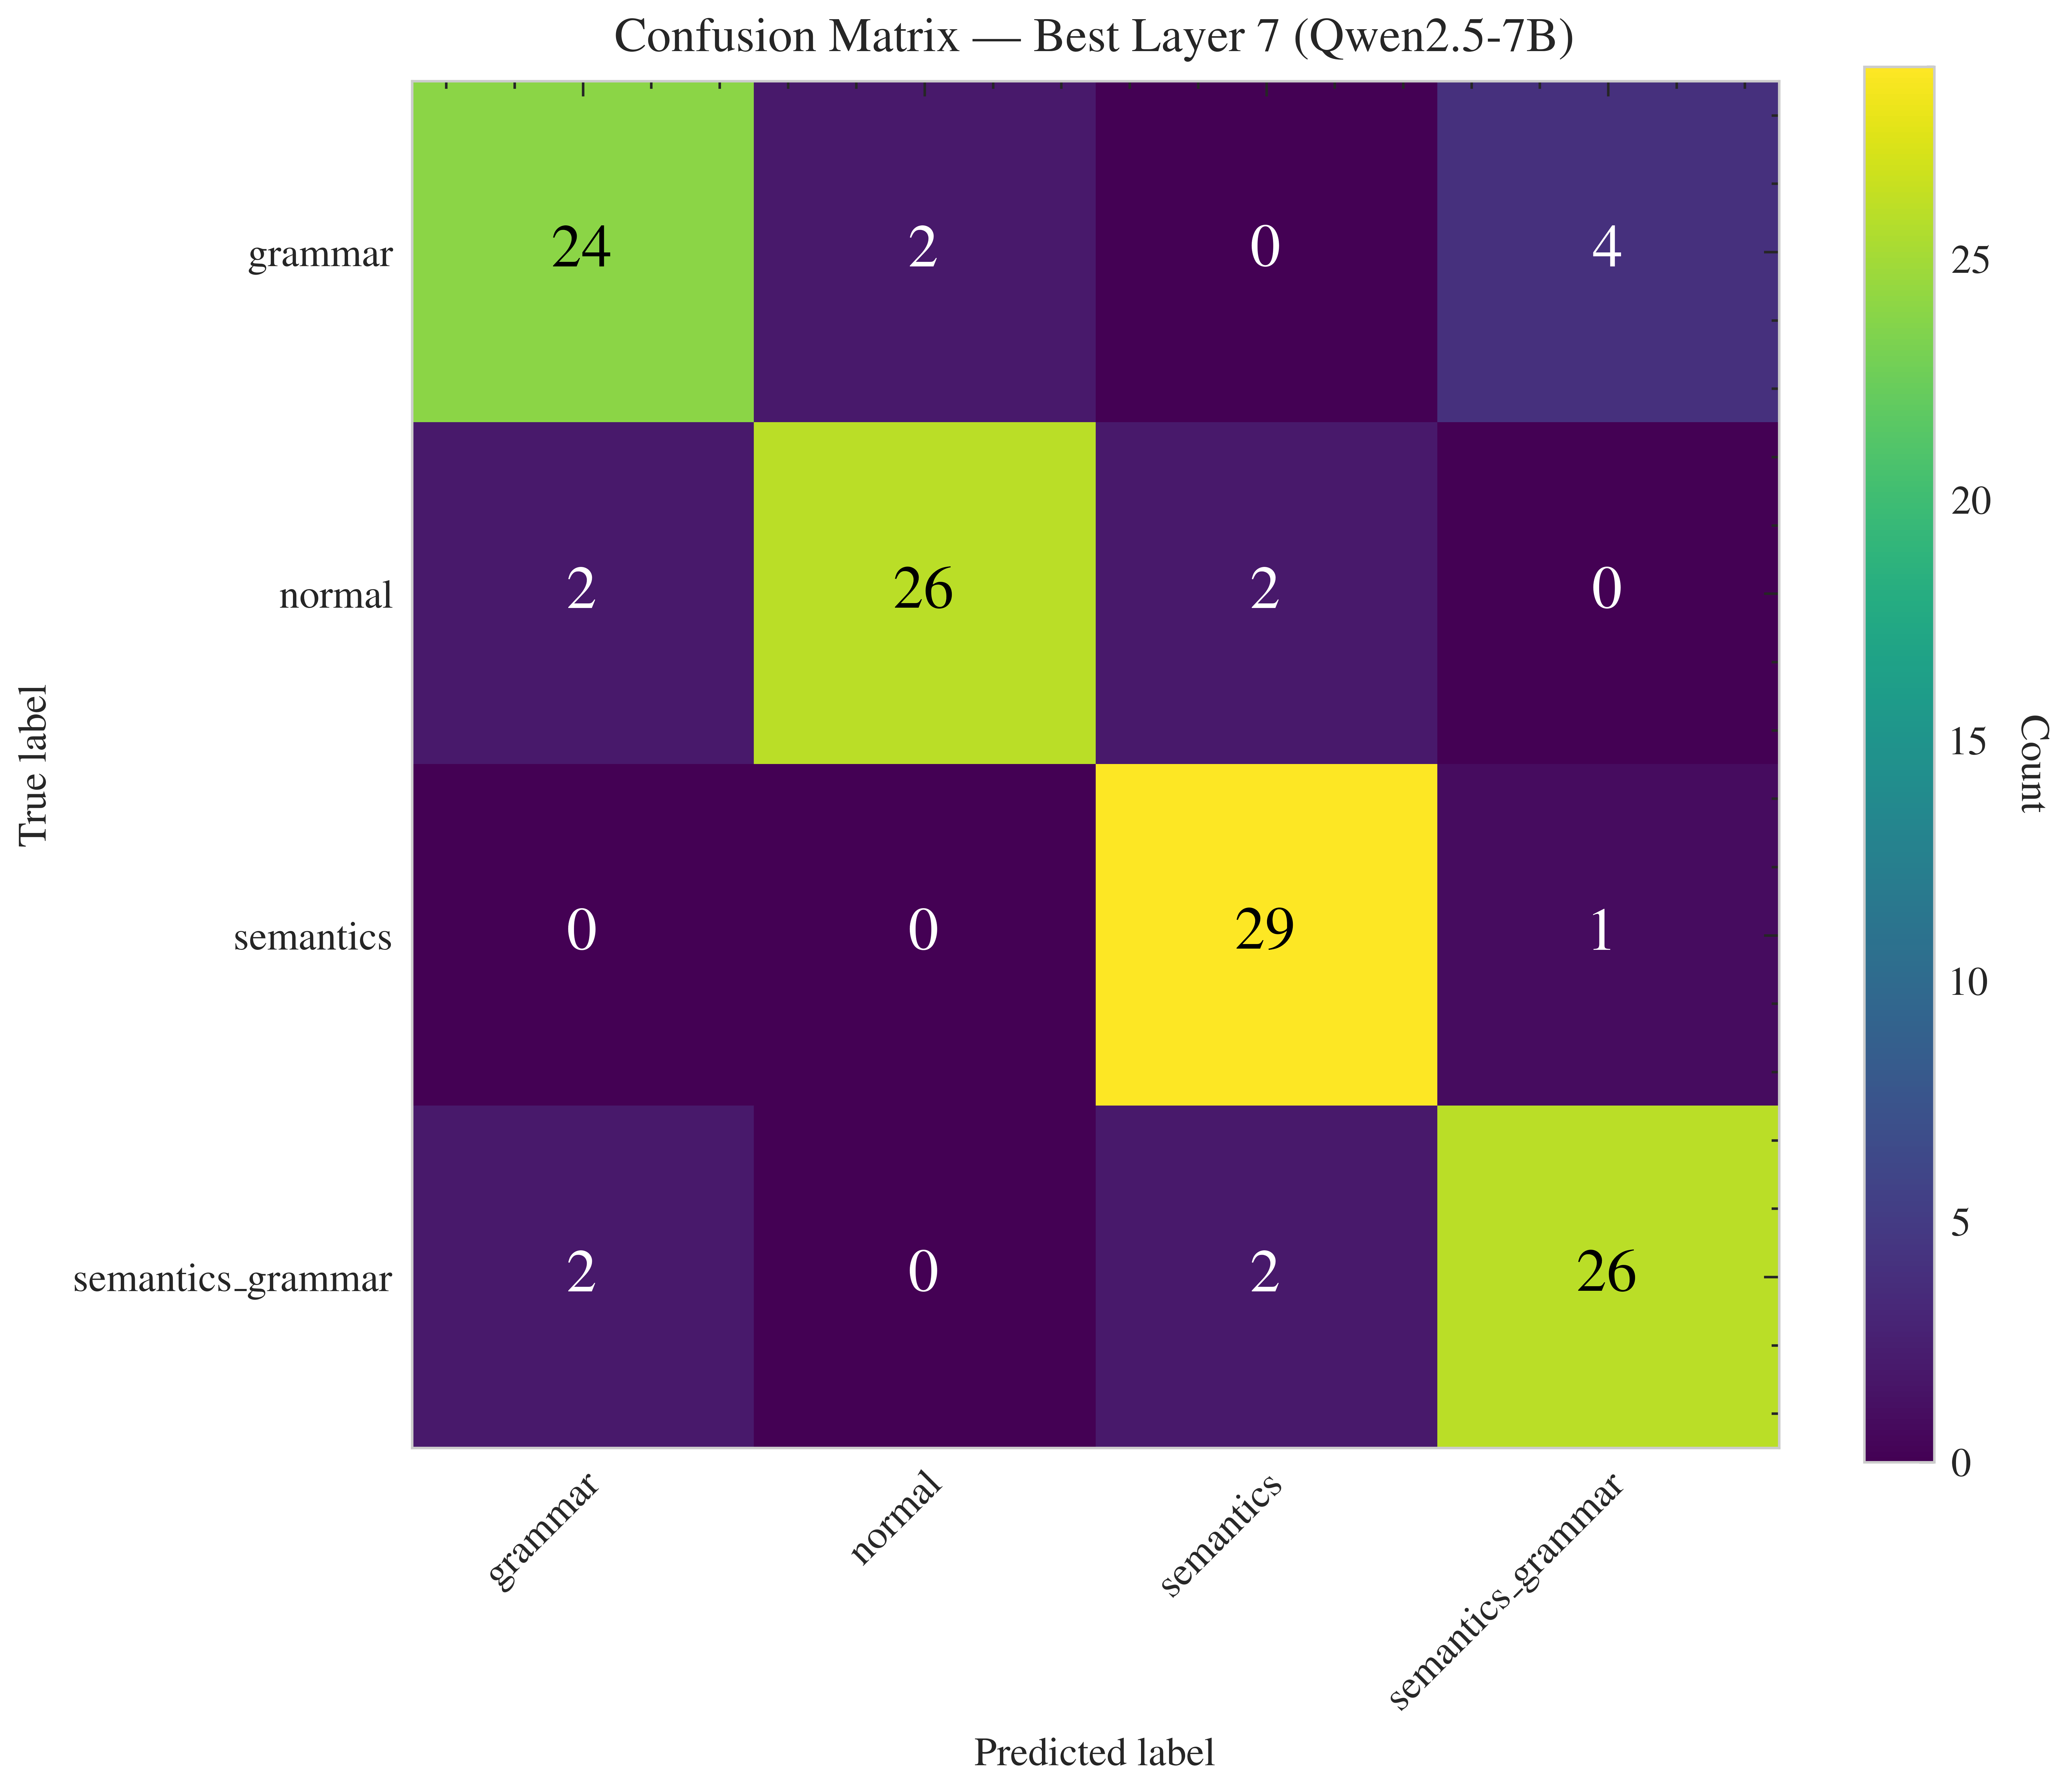

In [68]:
plot_confusion_matrix(
    qw_wl_best_conf,
    class_names=list(gc_wl_best_report.keys())[:-3],
    title=f"Confusion Matrix — Best Layer {gc_wl_best_layer} (Qwen2.5-7B)"
)

/var/folders/88/rz9pfrnd34q32tv5679ygvyh0000gn/T/ipykernel_45651/1428921389.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
2025-12-04 23:16:41 DEBUG    matplotlib.texmanager: family: serif, package: \usepackage{mathptmx}, font: Times, skipped: 
2025-12-04 23:16:41 DEBUG    matplotlib.texmanager: family: sans-serif, package: , font: sans-serif, skipped: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans
2025-12-04 23:16:41 DEBUG    matplotlib.texmanager: family: cursive, package: \usepackage{chancery}, font: Zapf Chancery, skipped: Apple Chancery, Textile
2025-12-04 23:16:41 DEBUG    matplotlib.texmanager: family: monospace, package: \usepackage{type1ec}, font: Computer Modern Typewriter, skipped: DejaVu Sans Mono, Bitstream Vera Sans Mono
2025-12-04 23:16:41 DEBUG    matplotlib.dviread: Dvi: /Users/ilyamikheev/.matplotlib/tex.cache/cc/87

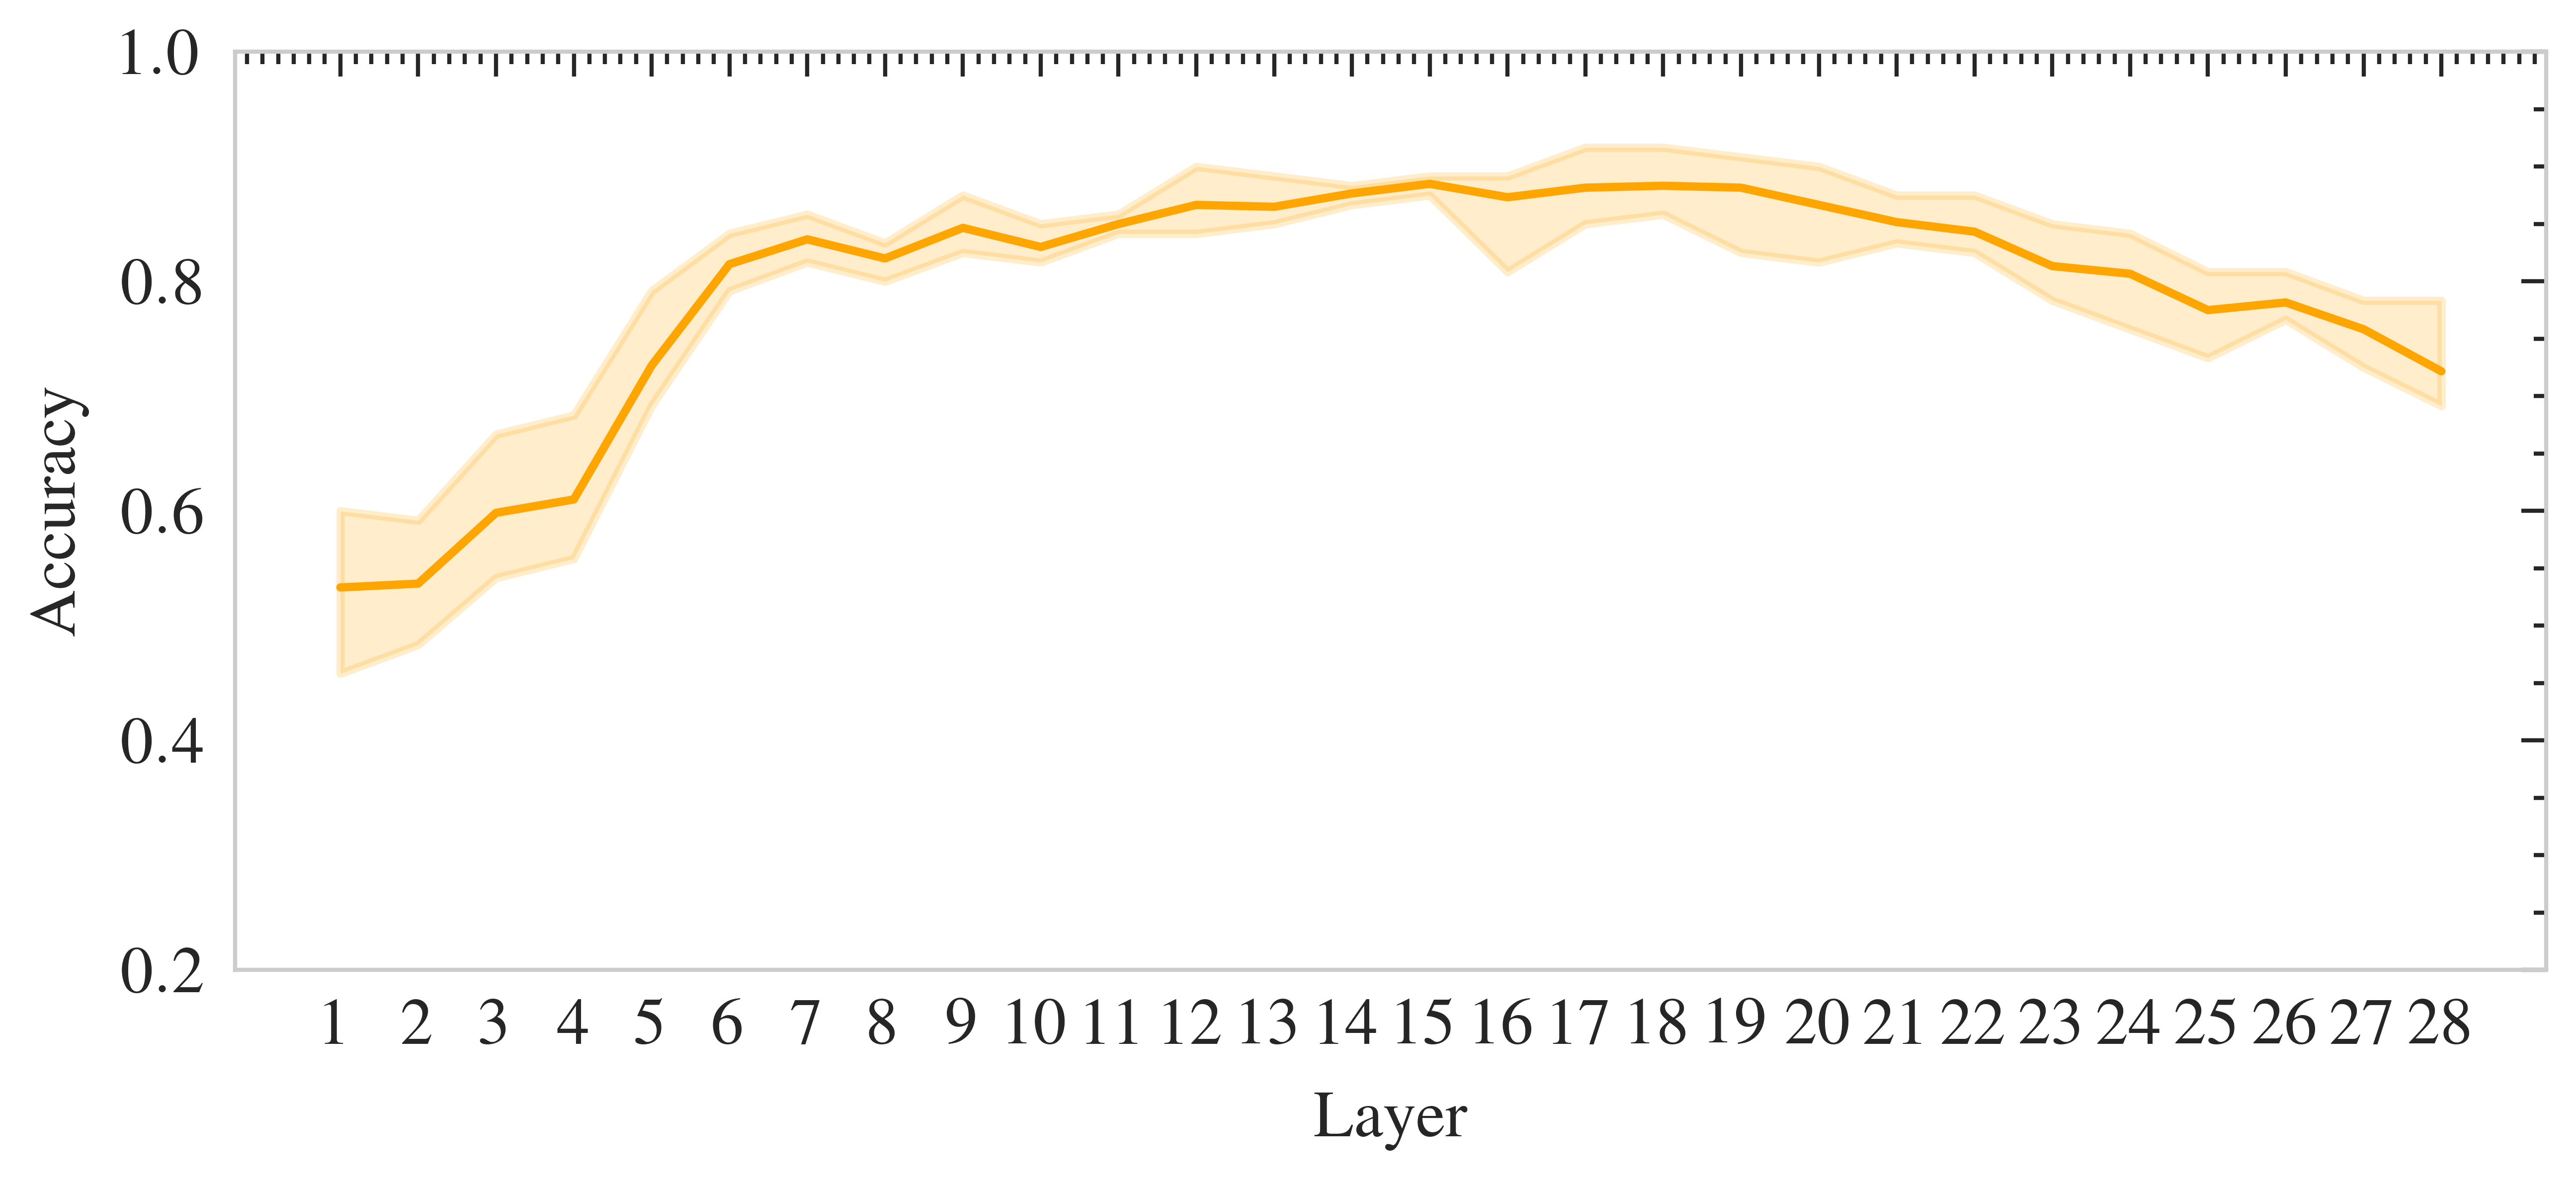

In [69]:
plot_min_max_corridor(qw_wl_all_layer_accs, color = "orange")

## Normal vs Grammar-incongruent

In [70]:
norm_vs_gramm_probing_results = {}
for k, v in tqdm(probing_datasets_dict.items(), desc="Probe fitting norm vs gramm"):
    norm_vs_gramm_probing_results[k] = probe_layers(df=v.word_level_dataset, target_labels=["normal", "grammar"])

Probe fitting norm vs gramm:   0%|          | 0/2 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable 

In [71]:
(gc_ng_wl_results,
 gc_ng_per_layer_reports,
 gc_ng_confusion_matrices,
 gc_ng_best_layer,
 gc_ng_best_report,
 gc_ng_best_conf,
 gc_ng_all_layer_accs) = norm_vs_gramm_probing_results["ai-sage/GigaChat3-10B-A1.8B-base"]

plot_min_max_corridor(gc_ng_all_layer_accs)
plot_confusion_matrix(
    gc_ng_best_conf,
    class_names=list(gc_ng_best_report.keys())[:-3],
    title=f"Confusion Matrix — Best Layer {gc_wl_best_layer} (Gigachat3-10B-A1.8B-base)"
)

Qwen

In [ ]:
(qw_ng__wl_results,
 qw_ng__wl_per_layer_reports,
 qw_ng__wl_confusion_matrices,
 qw_ng__wl_best_layer,
 qw_ng__wl_best_report,
 qw_ng__wl_best_conf,
 qw_ng__wl_all_layer_accs) = norm_vs_gramm_probing_results["Qwen/Qwen2.5-7B"]

plot_min_max_corridor(qw_ng__wl_all_layer_accs, color = "orange")
plot_confusion_matrix(
    qw_ng__wl_best_conf,
    class_names=list(qw_ng__wl_best_report.keys())[:-3],
    title=f"Confusion Matrix — Best Layer {qw_ng__wl_best_layer} (Qwen2.5-7B)"
)

### Grammar vs Semantic-Grammar incongruent

In [ ]:
norm_vs_gramm_probing_results

In [76]:
grammar_vs_semantics_grammar_probing_results = {}
for k, v in tqdm(probing_datasets_dict.items(), desc="Probe fitting grammar vs semantics grammar"):
    grammar_vs_semantics_grammar_probing_results[k] = probe_layers(df=v.word_level_dataset, target_labels=["grammar", "semantics_grammar"])

Probe fitting grammar vs semantics grammar:   0%|          | 0/2 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the enviro

In [79]:
grammar_vs_semantics_grammar_probing_results

{}

/var/folders/88/rz9pfrnd34q32tv5679ygvyh0000gn/T/ipykernel_45651/1428921389.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
2025-12-05 00:11:54 DEBUG    matplotlib.texmanager: family: serif, package: \usepackage{mathptmx}, font: Times, skipped: 
2025-12-05 00:11:54 DEBUG    matplotlib.texmanager: family: sans-serif, package: , font: sans-serif, skipped: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans
2025-12-05 00:11:54 DEBUG    matplotlib.texmanager: family: cursive, package: \usepackage{chancery}, font: Zapf Chancery, skipped: Apple Chancery, Textile
2025-12-05 00:11:54 DEBUG    matplotlib.texmanager: family: monospace, package: \usepackage{type1ec}, font: Computer Modern Typewriter, skipped: DejaVu Sans Mono, Bitstream Vera Sans Mono
2025-12-05 00:11:54 DEBUG    matplotlib.dviread: Dvi: /Users/ilyamikheev/.matplotlib/tex.cache/cc/87

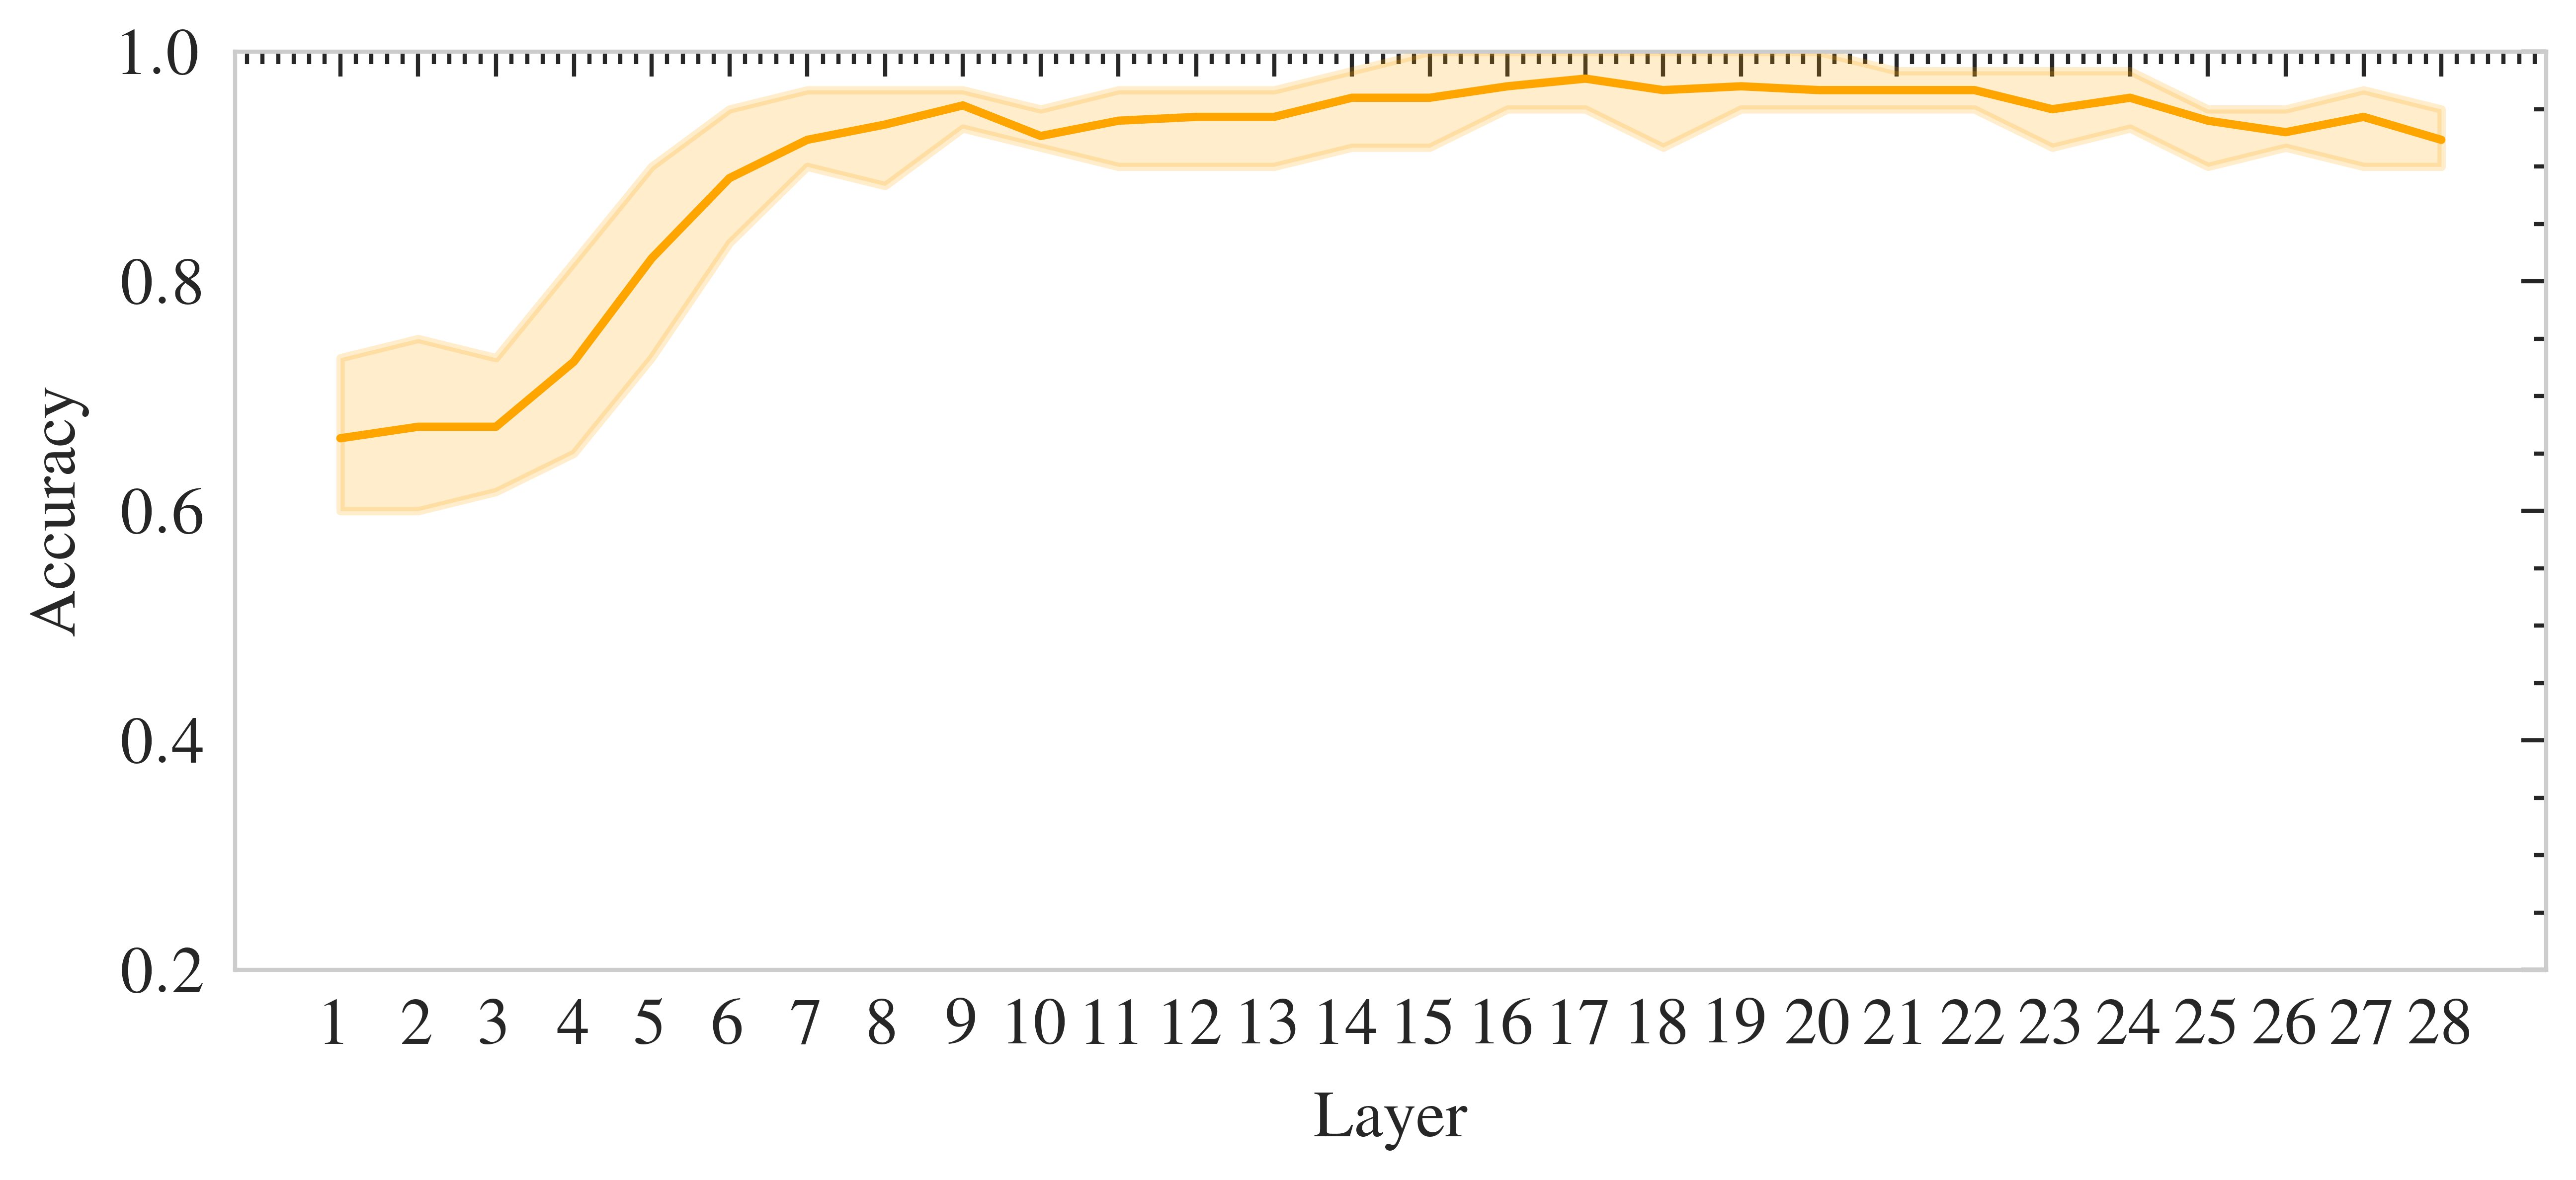

2025-12-05 00:11:55 DEBUG    matplotlib.colorbar: locator: <matplotlib.ticker.AutoLocator object at 0x342128890>
2025-12-05 00:11:55 DEBUG    matplotlib.texmanager: family: serif, package: \usepackage{mathptmx}, font: Times, skipped: 
2025-12-05 00:11:55 DEBUG    matplotlib.texmanager: family: sans-serif, package: , font: sans-serif, skipped: Arial, DejaVu Sans, Liberation Sans, Bitstream Vera Sans
2025-12-05 00:11:55 DEBUG    matplotlib.texmanager: family: cursive, package: \usepackage{chancery}, font: Zapf Chancery, skipped: Apple Chancery, Textile
2025-12-05 00:11:55 DEBUG    matplotlib.texmanager: family: monospace, package: \usepackage{type1ec}, font: Computer Modern Typewriter, skipped: DejaVu Sans Mono, Bitstream Vera Sans Mono
2025-12-05 00:11:55 DEBUG    matplotlib.dviread: Dvi: /Users/ilyamikheev/.matplotlib/tex.cache/cc/87/cc870fece1f1d8c03f0c28a153846cdcaffcfd008433626efcf5398762972285.dvi
2025-12-05 00:11:55 DEBUG    matplotlib.dviread: Dvi._xxx: encountered special: heade

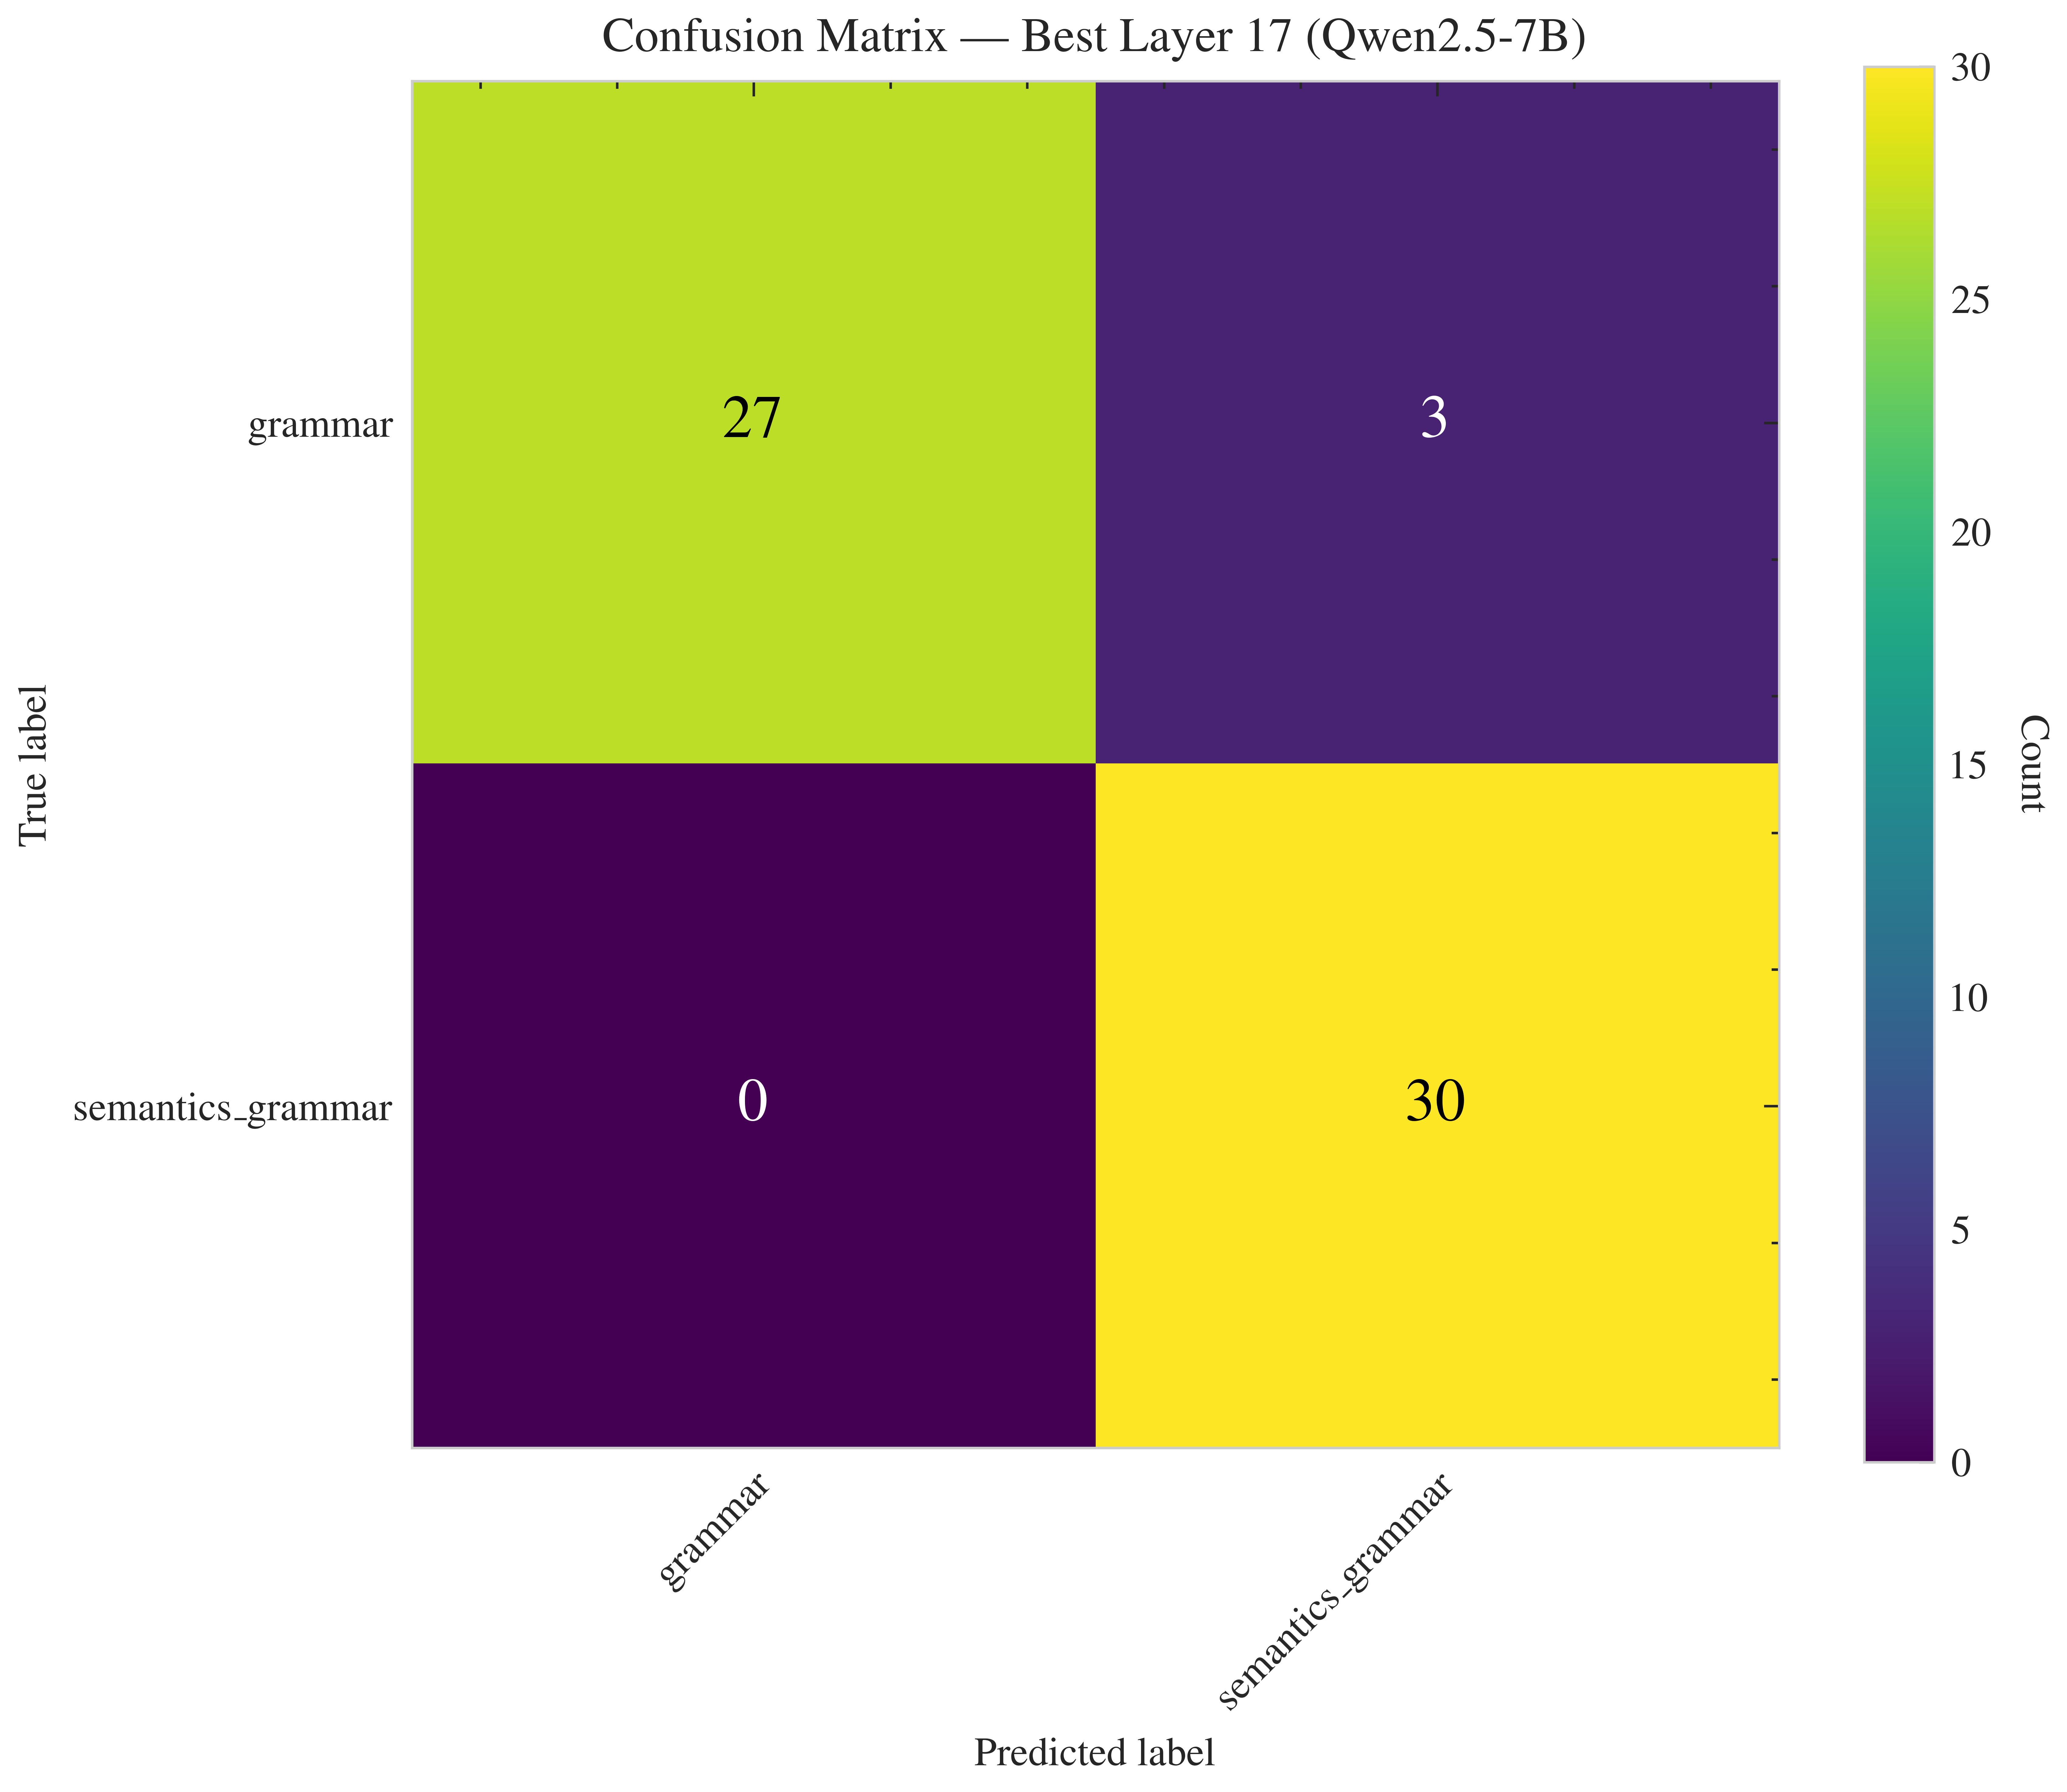

In [82]:
# model_name = "ai-sage/GigaChat3-10B-A1.8B-base"
model_name = "Qwen/Qwen2.5-7B"

(gc_gsg_wl_results,
 gc_gsg_per_layer_reports,
 gc_gsg_confusion_matrices,
 gc_gsg_best_layer,
 gc_gsg_best_report,
 gc_gsg_best_conf,
 gc_gsg_all_layer_accs) = norm_vs_gramm_probing_results[model_name]

plot_min_max_corridor(gc_gsg_all_layer_accs, color = "orange")
plot_confusion_matrix(
    gc_gsg_best_conf,
    class_names=list(gc_gsg_best_report.keys())[:-3],
    title=f"Confusion Matrix — Best Layer {gc_gsg_best_layer} ({model_name.split('/')[1]})"
)